# Precursor analysis — what the agent does before a multi-year ENSO onset

This notebook studies the agent's **forcing in the months leading up to** each
multi-year El Niño (MYEN) / La Niña (MYLN) onset, reading the same
`inference.npz` that `analysis.ipynb` uses.

It answers two distinct questions:

1. **Pre-onset fingerprint (few months before).** What forcing configuration
   immediately precedes an onset? This is *forecasting-relevant*, but — because the
   policy saturates — it reports the *sign/direction* of each driver, not the
   mechanism, and is essentially identical for a 3- vs 6-month window.
2. **Driving mechanism (lead-time profile, ~24 months).** *When* does the agent move
   each mode, and in what order? The real decision-making happens **~8–18 months
   out**, much of it *inside the dying opposite-phase event* (the agent recharges WWV
   for the next event — a recharge-oscillator signature). The **sequencing** of modes
   is the insight an RL agent gives that a linear precursor analysis cannot.

**Caveat.** This is the *agent's learned control strategy*, not a claim about
real-world ENSO precursors. Statistics are **clustered at the training-seed level**
(n≈10); naively pooling the ~6,000 events per phase would give confidence intervals
~9–29× too narrow.

In [ ]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..").resolve()))
from utils.nb_helper import PHASE_LABELS, XRO_MODES, _mean_ci, _load_npz
from utils.enso_classifier import _find_continuous_runs
from config import EnvConfig

NAME  = "model10"                      # matches --model used when running inference
BASE  = Path("..") / "plots" / NAME
OUTDIR = BASE / "precursor"
OUTDIR.mkdir(parents=True, exist_ok=True)

LEAD  = 24                             # max lead (months before onset) to analyse
CODES = {"el_nino": 3, "la_nina": 4}   # MYE label codes (3 = MY El Niño, 4 = MY La Niña)
MODE_COLORS = dict(zip(XRO_MODES, plt.cm.tab10(np.linspace(0, 1, 10))))

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 11, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
})

d = _load_npz(BASE / "inference.npz")
acts   = d["agent_actions"].astype(np.float64)   # [S,R,T,9] scaled forcing
labels = d["agent_mye_label"]                    # [S,R,T] int8
start_month = d["rollout_start_month"]           # [S,R] 0-based calendar month of step 0
names  = list(d["action_names"])
S, R, T, M = acts.shape
spin = int(d["spinup"])
assert names == XRO_MODES, "action-mode order mismatch"
print(f"seeds={S}  rollouts={R}  months(T)={T}  modes={M}  spinup={spin}")

seeds=10  rollouts=30  months(T)=1200  modes=9  spinup=12


## 1. Recover raw actions and de-seasonalize

Stored `agent_actions` are scaled by the per-mode, per-month `action_scale` (indexed
by `step % 12` at write time). Dividing by that **same** factor recovers the raw
policy action in `[-1, 1]` and cancels the known month-offset scaling bug exactly
(this mirrors the correct cells 29/30 of `analysis.ipynb`).

For the lead-time profile we also remove seasonality by subtracting each mode's
climatological mean action **by true calendar month** `(step + rollout_start_month) %
12` — necessary because onsets cluster in boreal spring.

In [2]:
# Raw policy action in [-1, 1]
scale = np.array(EnvConfig().action_scale)              # [9,12], already halved in __post_init__
raw = acts / scale[:, np.arange(T) % 12].T              # [S,R,T,9]
assert raw.min() >= -1.001 and raw.max() <= 1.001, "raw action outside [-1,1]"

# De-seasonalize by TRUE calendar month
cal = (np.arange(T)[None, None, :] + start_month[:, :, None]) % 12   # [S,R,T]
keep = np.arange(T) >= spin
clim = np.stack([raw[(cal == m) & keep[None, None, :]].mean(0) for m in range(12)])  # [12,9]
anom = raw - clim[cal]                                   # [S,R,T,9]

print(f"raw range = [{raw.min():.3f}, {raw.max():.3f}]")
print(f"saturation |raw|>0.99 (post-spinup) = {100*(np.abs(raw[:,:,spin:])>0.99).mean():.1f}%"
      "  -> composites mostly report SIGNS, not graded magnitudes")

raw range = [-1.000, 1.000]
saturation |raw|>0.99 (post-spinup) = 74.6%  -> composites mostly report SIGNS, not graded magnitudes


## 2. Locate multi-year event onsets

For each `(seed, rollout)` we find every contiguous run of a phase label; each run's
start index is that event's **onset**. We keep only onsets with a full `LEAD`-month
window that clears the spin-up period.

In [3]:
events = {p: [] for p in CODES}                  # p -> list of (si, ri, t0)
for p, code in CODES.items():
    for si in range(S):
        for ri in range(R):
            for s0, e0, L in _find_continuous_runs((labels[si, ri] == code).astype(int)):
                if s0 - LEAD >= spin:
                    events[p].append((si, ri, s0))
for p in CODES:
    print(f"{PHASE_LABELS[p]:22s}: {len(events[p]):5d} onset events (full {LEAD}-mo window)")

Multi-year El Niño    :  6123 onset events (full 24-mo window)
Multi-year La Niña    :  6109 onset events (full 24-mo window)


## 3. Lead-time driver profile — primary result

For every mode we composite the **de-seasonalized** action over the 24 months before
onset. We aggregate **per seed first**, then take the mean and 95% CI **across seeds**
(the correct clustering). The ordering in which modes depart from zero is the
sequencing signature.

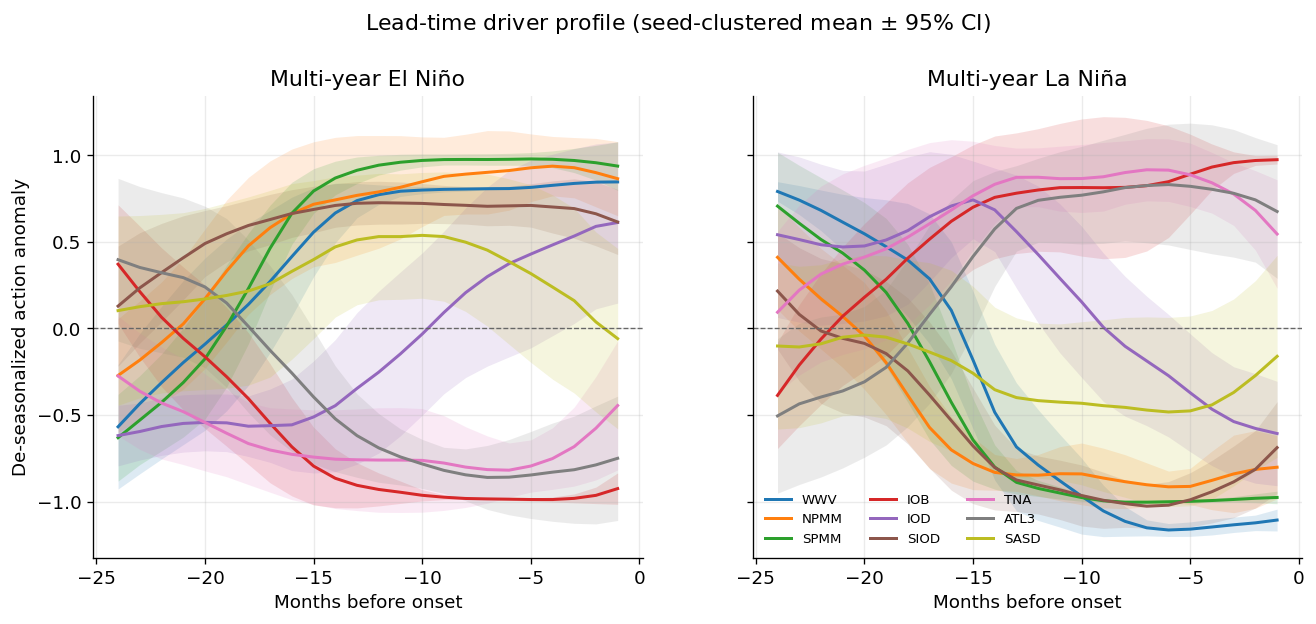

In [5]:
def leadtime_profile(ev, arr):
    # Seed-clustered lead-time composite. Returns mean[LEAD,9], ci[LEAD,9].
    per_seed = np.full((S, LEAD, M), np.nan)
    for si in range(S):
        wins = [arr[s, r, t0 - LEAD:t0, :] for (s, r, t0) in ev if s == si]
        if wins:
            per_seed[si] = np.mean(wins, axis=0)
    mean = np.full((LEAD, M), np.nan); ci = np.full((LEAD, M), np.nan)
    for k in range(LEAD):
        for mi in range(M):
            col = per_seed[~np.isnan(per_seed[:, k, mi]), k, mi]
            if len(col) > 1:
                mean[k, mi], ci[k, mi] = _mean_ci(col)
    return mean, ci

prof = {p: leadtime_profile(events[p], anom) for p in CODES}
lags = np.arange(-LEAD, 0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, p in zip(axes, CODES):
    mean, ci = prof[p]
    for mi, nm in enumerate(names):
        ax.plot(lags, mean[:, mi], color=MODE_COLORS[nm], lw=1.8, label=nm)
        ax.fill_between(lags, mean[:, mi] - ci[:, mi], mean[:, mi] + ci[:, mi],
                        color=MODE_COLORS[nm], alpha=0.15, lw=0)
    ax.axhline(0, color="0.4", lw=0.8, ls="--")
    ax.set_title(PHASE_LABELS[p]); ax.set_xlabel("Months before onset")
axes[0].set_ylabel("De-seasonalized action anomaly")
axes[1].legend(ncol=3, fontsize=8, frameon=False, loc="lower left")
fig.suptitle("Lead-time driver profile (seed-clustered mean $\\pm$ 95% CI)", y=1.02)
fig.savefig(OUTDIR / "07a_precursor_leadtime.png")
plt.show()

## 4. Pre-onset fingerprint table

Mean **raw** action over the 3- and 6-month windows immediately before onset, per
mode and phase, with seed-clustered 95% CIs. Because the policy is saturated, this is
the pre-onset *fingerprint* (direction of each driver). The 3- and 6-month columns
agree in sign on all 9 modes — the window length does not matter here.

In [5]:
def fingerprint(ev, arr, L):
    per_seed = np.full((S, M), np.nan)
    for si in range(S):
        wins = [arr[s, r, t0 - L:t0, :].mean(0) for (s, r, t0) in ev if s == si]
        if wins:
            per_seed[si] = np.mean(wins, axis=0)
    return {mi: _mean_ci(per_seed[~np.isnan(per_seed[:, mi]), mi]) for mi in range(M)}

rows = []
for p in CODES:
    for L in (3, 6):
        fp = fingerprint(events[p], raw, L)
        for mi, nm in enumerate(names):
            m, c = fp[mi]
            rows.append(dict(phase=p, window_mo=L, mode=nm, mean=round(m, 3), ci95=round(c, 3)))
fp_df = pd.DataFrame(rows)
fp_df.to_csv(OUTDIR / "precursor_fingerprint.csv", index=False)

for p in CODES:
    s3 = fp_df[(fp_df.phase == p) & (fp_df.window_mo == 3)].set_index("mode")["mean"]
    s6 = fp_df[(fp_df.phase == p) & (fp_df.window_mo == 6)].set_index("mode")["mean"]
    print(f"{PHASE_LABELS[p]}: 3-mo vs 6-mo sign agreement = {int((np.sign(s3)==np.sign(s6)).sum())}/9")

# Readable pivot: modes x (phase, window)
pivot = fp_df.pivot_table(index="mode", columns=["phase", "window_mo"], values="mean").reindex(XRO_MODES)
pivot

Multi-year El Niño: 3-mo vs 6-mo sign agreement = 9/9
Multi-year La Niña: 3-mo vs 6-mo sign agreement = 9/9


phase     el_nino        la_nina       
window_mo       3      6       3      6
mode                                   
WWV         0.999  0.998  -0.966 -0.969
NPMM        0.862  0.881  -0.856 -0.890
SPMM        0.952  0.967  -0.985 -0.989
IOB        -0.953 -0.973   0.973  0.928
IOD         0.450  0.358  -0.702 -0.620
SIOD        0.826  0.864  -0.628 -0.707
TNA        -0.598 -0.713   0.637  0.739
ATL3       -0.778 -0.816   0.740  0.774
SASD        0.027  0.175  -0.285 -0.369

## 5. Driver sequencing

For each mode, the lead (months before onset) at which its de-seasonalized composite
**last settled into its onset-time sign** — i.e. how early the agent commits that
driver. Modes near the top act earliest.

In [6]:
def sequencing(ev, arr):
    mean, _ = leadtime_profile(ev, arr)
    out = {}
    for mi, nm in enumerate(names):
        col = mean[:, mi]
        diff = np.where(np.sign(col) != np.sign(col[-1]))[0]
        out[nm] = float(LEAD) if len(diff) == 0 else float(LEAD - diff[-1])  # >LEAD -> LEAD
    return out

seq_df = pd.DataFrame({PHASE_LABELS[p]: sequencing(events[p], anom) for p in CODES}).reindex(XRO_MODES)
seq_df.index.name = "mode  (settling lead, months before onset; =24 means >24)"
seq_df.to_csv(OUTDIR / "precursor_sequencing.csv")
seq_df.sort_values(seq_df.columns[0], ascending=False)

,Multi-year El Niño,Multi-year La Niña
"mode (settling lead, months before onset; =24 means >24)",,
SIOD,24.0,23.0
TNA,24.0,24.0
NPMM,22.0,21.0
IOB,22.0,22.0
WWV,20.0,16.0
SPMM,20.0,18.0
ATL3,18.0,18.0
IOD,10.0,9.0
SASD,2.0,24.0


## 6. Recharge check — forcing during the dying opposite event

Because events alternate every ~2 years, much of the pre-onset window falls **inside
the previous, opposite-phase event**. The agent is already driving WWV in the
next event's direction *while the old event is still running* — the recharge. Below:
the fraction of events still inside the opposite MY event at each lag, and the WWV
forcing, showing it is already saturated before onset.

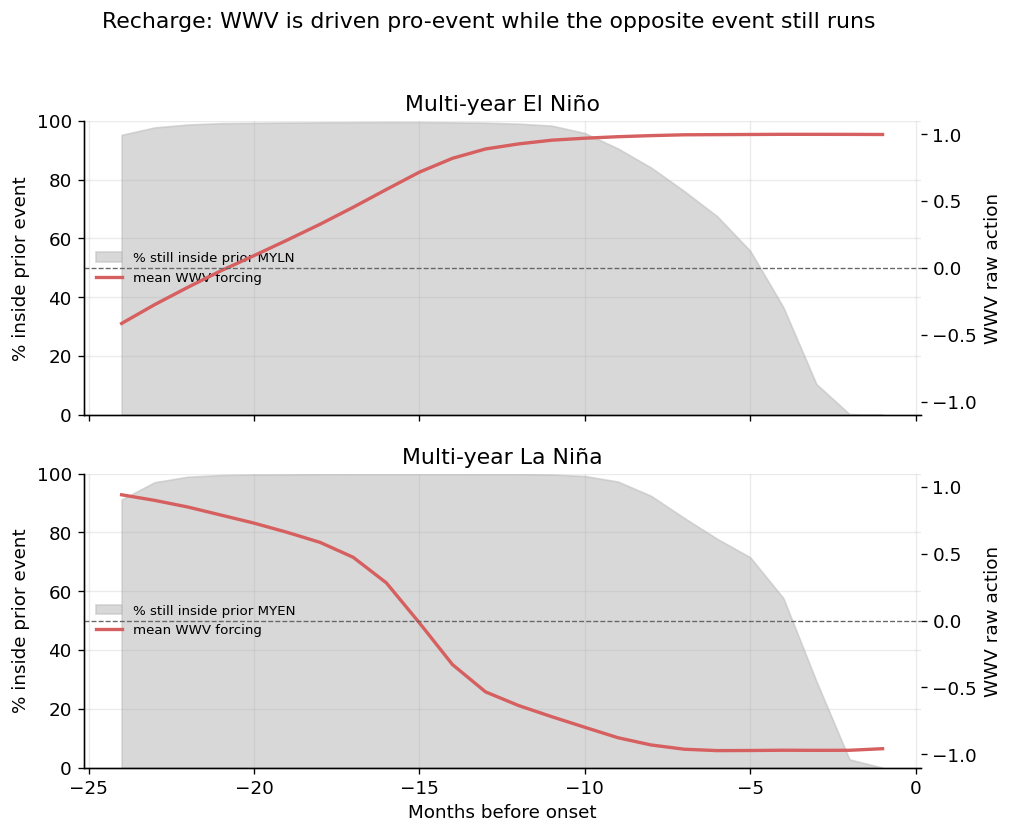

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
for ax, p in zip(axes, CODES):
    code = CODES[p]; opp = 4 if code == 3 else 3
    ev = events[p]
    Lb  = np.stack([labels[s, r, t0 - LEAD:t0]                    for (s, r, t0) in ev])   # [n,LEAD]
    Wwv = np.stack([raw[s, r, t0 - LEAD:t0, names.index("WWV")]   for (s, r, t0) in ev])   # [n,LEAD]
    frac = 100 * (Lb == opp).mean(0)
    ax.fill_between(lags, 0, frac, color="0.75", alpha=0.6,
                    label=f"% still inside prior {'MYLN' if opp==4 else 'MYEN'}")
    ax.set_ylabel("% inside prior event"); ax.set_ylim(0, 100)
    ax2 = ax.twinx(); ax2.grid(False)
    ax2.plot(lags, Wwv.mean(0), color="#D65F5F", lw=2, label="mean WWV forcing")
    ax2.axhline(0, color="0.4", lw=0.8, ls="--"); ax2.set_ylabel("WWV raw action"); ax2.set_ylim(-1.1, 1.1)
    ax.set_title(PHASE_LABELS[p])
    l1, la1 = ax.get_legend_handles_labels(); l2, la2 = ax2.get_legend_handles_labels()
    ax.legend(l1 + l2, la1 + la2, fontsize=8, frameon=False, loc="center left")
axes[-1].set_xlabel("Months before onset")
fig.suptitle("Recharge: WWV is driven pro-event while the opposite event still runs", y=1.01)
fig.savefig(OUTDIR / "07b_precursor_recharge.png")
plt.show()

## 7. Robustness caveats

- **Reward-band question.** Median event duration sits right at the reward's
  duration ceiling (24 months). A reviewer will ask whether the agent found genuine
  precursors or is exploiting that band — flagged here explicitly.
- **Saturation.** The policy is at the ±1 bound most of the time, so the composites
  above report the *direction* of each driver, not a graded magnitude.
- **Clustering.** All CIs are across the n≈10 training seeds; pooling individual
  events would understate the uncertainty by ~9–29×.

In [8]:
dur = {}
for p, code in CODES.items():
    d_list = [L for si in range(S) for ri in range(R)
              for _s, _e, L in _find_continuous_runs((labels[si, ri] == code).astype(int))]
    dur[p] = d_list
    print(f"{PHASE_LABELS[p]:22s}: median duration = {np.median(d_list):.1f} mo "
          f"(reward ceiling = 24)  |  n = {len(d_list)} events")
print(f"\nSaturation |raw|>0.99 (post-spinup): {100*(np.abs(raw[:,:,spin:])>0.99).mean():.1f}%")
print(f"Figures + tables written to: {OUTDIR}")

Multi-year El Niño    : median duration = 23.0 mo (reward ceiling = 24)  |  n = 6368 events
Multi-year La Niña    : median duration = 24.0 mo (reward ceiling = 24)  |  n = 6306 events

Saturation |raw|>0.99 (post-spinup): 74.6%
Figures + tables written to: ../plots/model10/precursor


## Takeaways

- **The pre-onset fingerprint is stable but shallow.** 3- and 6-month windows give the
  same signs (9/9, both phases): the few-months view tells you *which way* each driver
  points, not *how* the event was built.
- **The mechanism lives 8–18 months out.** WWV, SPMM and the inter-basin modes commit
  their sign well over a year before onset; IOD and SASD move latest. This *sequencing*
  is the RL-specific insight.
- **It is a recharge strategy.** A large fraction of the lead window sits inside the
  prior opposite event, during which the agent already drives WWV in the next event's
  direction — the recharge-oscillator signature.
- Treat all of this as the **agent's learned strategy**; bridge to observed ENSO
  precursors only where they align, and keep the reward-ceiling caveat in view.